### 1 Faithfulness


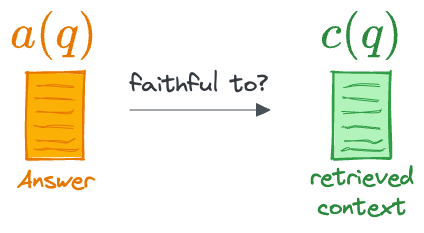

Step 1: Extract statements

Given a question and its generated answer, the LLM first extracts a set of assertions represented as S(a(q), where each assertion is an individual statement si that makes specific si that makes secific claim.


Step 2: Verify each statement


for each assertion si in S the LLM evaluate whether it can be infered from the context

### 1 Faithfulness


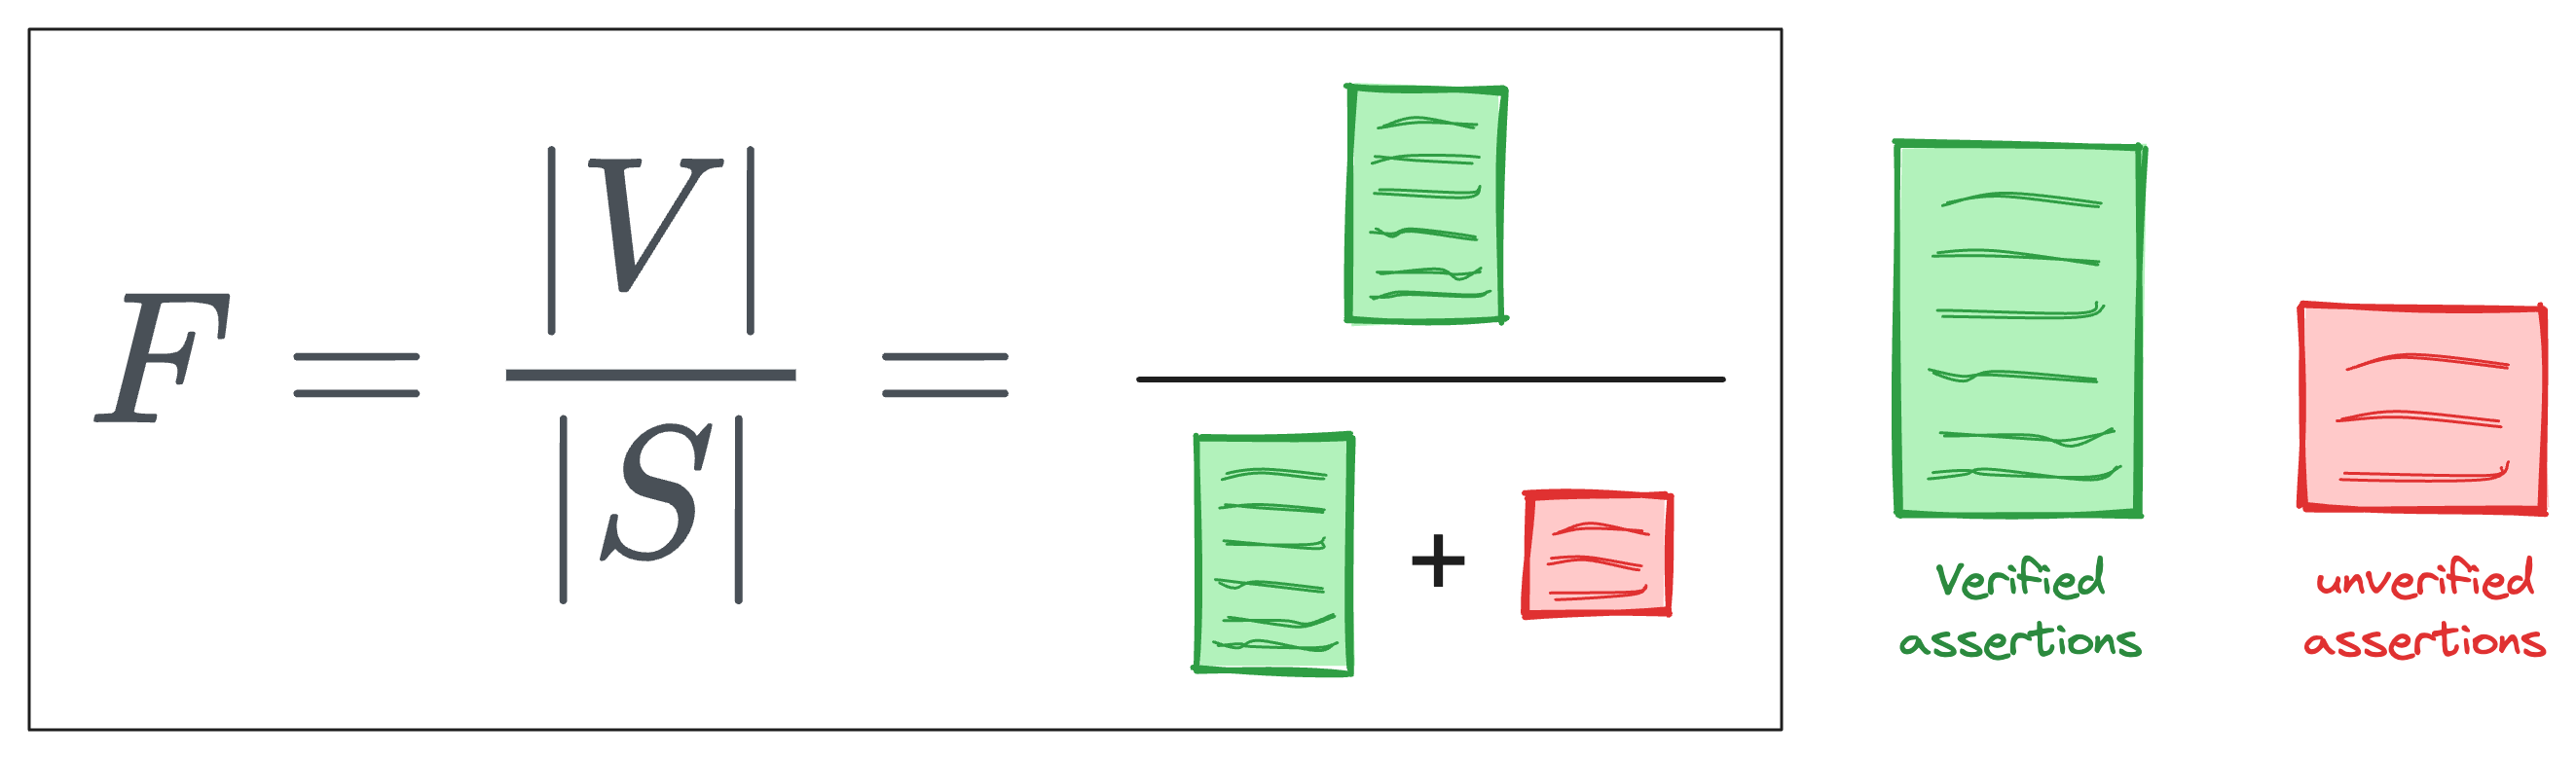

Step 1: Extract statements

Given a question and its generated answer, the LLM first extracts a set of assertions represented as S(a(q), where each assertion is an individual statement si that makes specific si that makes secific claim.


Step 2: Verify each statement



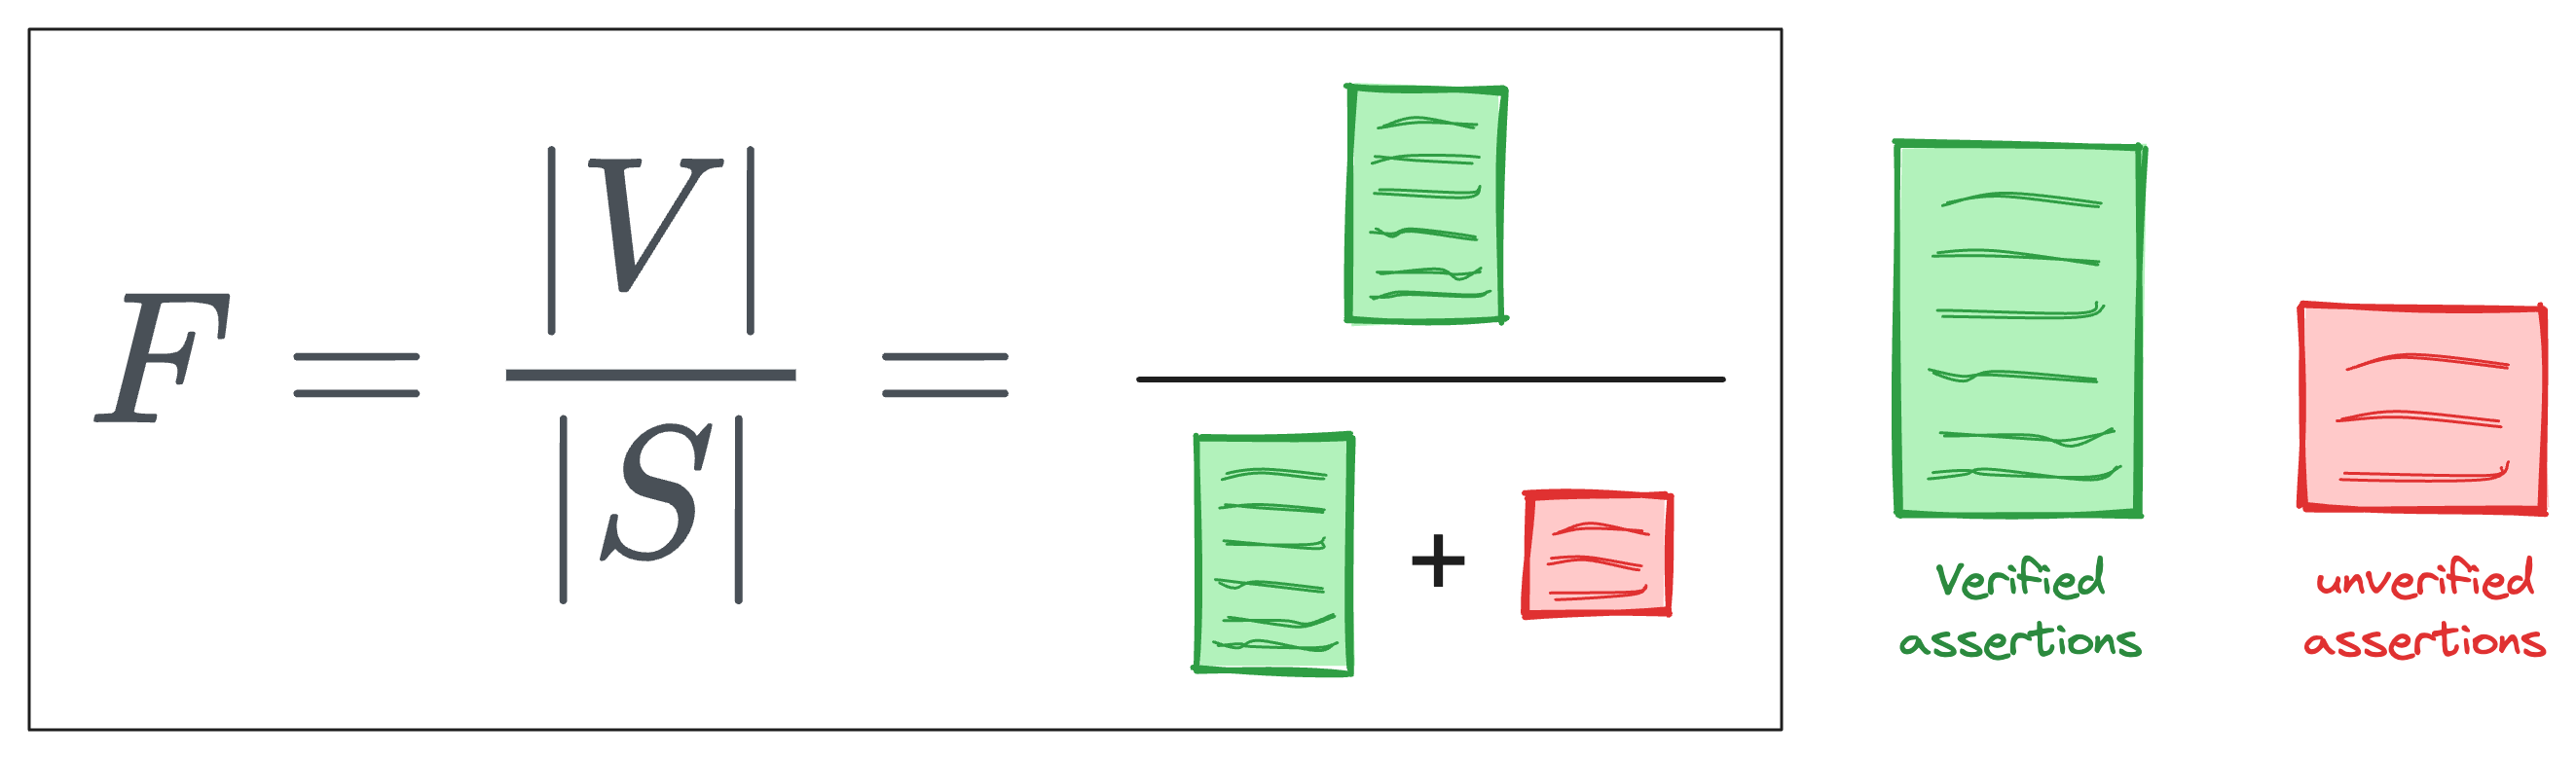


### 2) Answer relevance
Answer Relevance measures whether the generated answer a(q) directly address the user's query in a meaningful and complete way.
This metric focuses on the relevance of the response rather than its factual accuracy.

##### Step 1: Generate proxy questions

For a given answer  a(q), we prompt the language model to generate a series of alternative question for that answer will the same

*Generate a question for the given answer.*

Answer is *Machine i the methamitical relationship between Ip and op*

This prompt lets us create a set of  n alternative questions

##### Step 2: Calculate similarity scores

Once we have the original question q and the generated set of proxy  questions q1, q2, q3, q4 ....qn. we use embeddings to calculate simarity score

More specifically, obtain embeddings for the original question q and each generated question qi.

Next, Calculate the cosine similarity sim(q,qi) between the embedding of q and generated question qi.


The cosine similarity score indicates how closely each proxy question aligns with the original question’s meaning.

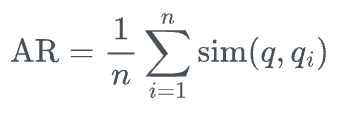

Example
--------

q = What is ML

q1 = what do you mean by ML

q2 = are you about ML


SIM(q,q1) + SIM(q,q2)

AR = 1/2(0.8+0.75)

### 3 Context relevance (How relevant is my context?)

To evaluate context relevance, the following approach can be used:

### Step 1: Extract relevant sentences

for the given question q and the corresponding context c(q) retrived from the vector database, the LLM is asked to identify only the curcial sentences for answering q.

Prompt Example:

*Extract relevant sentences from the provided context that can potentially help answer the following question. If no relevant sentences are found, or if you believe the question cannot be answered from the given context, return the phrase 'Insufficient Information.' While extracting candidate sentences, you’re not allowed to make any changes to sentences from the given context.*


This prompt guides the LLM to scan c(q) and select only the sentences that contribute directly to answering q. By Using the tag *Insufficiient Information*  the prompt also account for cases where the context does not contain any useful information.

### Step 2: Calculate the context relevance score
--------------------------------------------------
Once the subset Si is extracted, the context relevence (CR) score computed as the ratio of the number of extracted sentences to the total number of senetences in original context c(q)

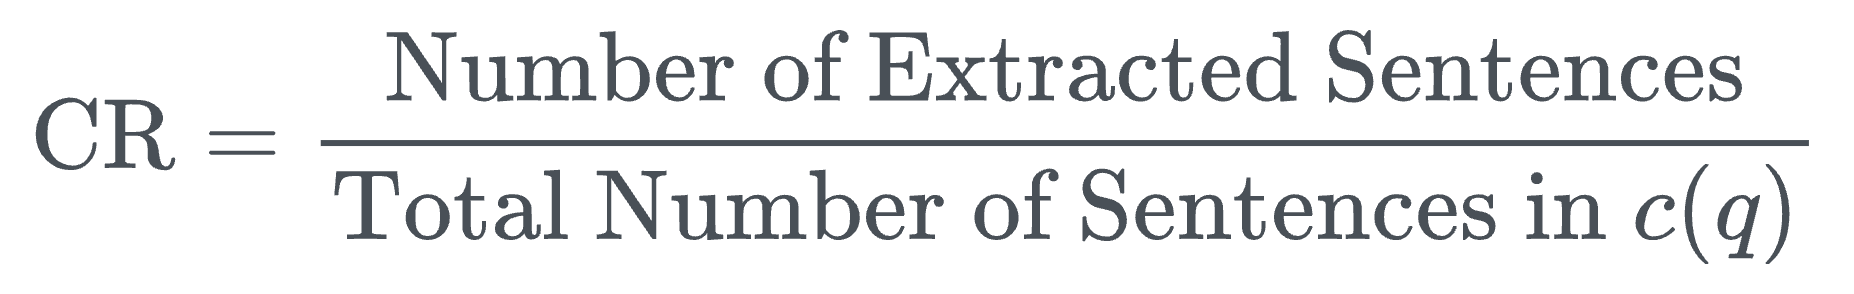

# 4) Answer correctness

Answer correctness considers two key aspects—the semantic similarity between the generated answer and the ground truth,, as well as the factual Similarity

This requires two models:

A critic LLM determines factual correctness by measuring the similarity between the generated answer and the ground truth answer using a critic llm.

An embedding model computes the embeddings for the generated answer and the ground truth and then measures the cosine similarity. This helps in determining the semantic similarity.

Prompt example:

*Given a ground truth and an answer, analyze each statement in the answer and classify them in one of the following categories:*


*TP (true positive): statements that are present in both the answer and the ground truth,*

*- FP (false positive): statements present in the answer but not found in the ground truth,*

** - FN (false negative): relevant statements found in the ground truth but omitted in the answer.*


Factiual Correctness score = TP/(TP+0.5*(FP+FN))


#### 5.  Context recall
-------------------------
Context recall measures how much the retrieved context aligns with the ground truth answer, using a critic llm.

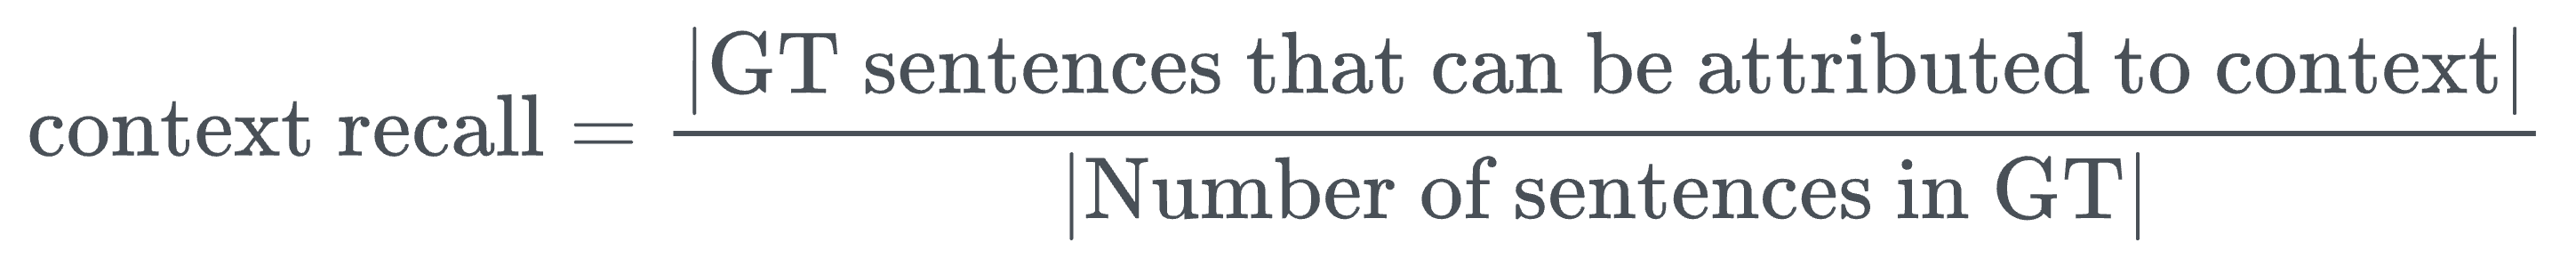


### 6. Context precision
-------------------------

Context precision measures if all relevant items in the  *context* are ranked high or not. Thus it checks how precise the fetched context is

